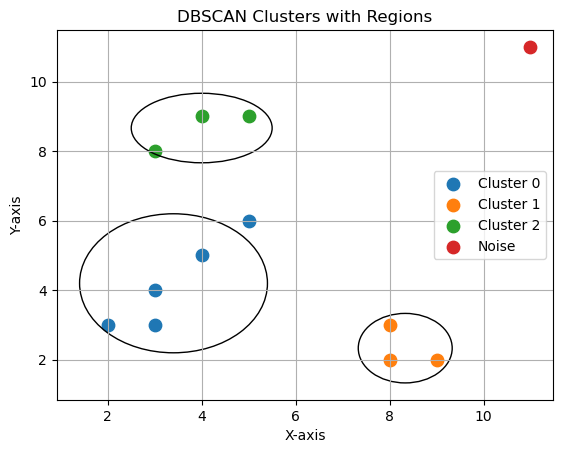

Cluster Labels: [ 0  0  0  0  0  1  1  1  2  2  2 -1]


In [1]:
# DBSCAN with cluster boundary visualization

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from matplotlib.patches import Ellipse

# Step 1: Static dataset (similar to hand-drawn layout)
X = np.array([
    [2, 3], [3, 3], [3, 4], [4, 5], [5, 6],   # Cluster 1
    [8, 2], [8, 3], [9, 2],                   # Cluster 2
    [3, 8], [4, 9], [5, 9],                   # Cluster 3
    [11, 11]                                  # Noise
])

# Step 2: Apply DBSCAN
dbscan = DBSCAN(eps=2, min_samples=2)
labels = dbscan.fit_predict(X)

# Step 3: Plot points
plt.figure()

unique_labels = set(labels)

for label in unique_labels:

    if label == -1:
        # Noise points
        plt.scatter(
            X[labels == label, 0],
            X[labels == label, 1],
            s=80,
            label="Noise"
        )

    else:
        cluster_points = X[labels == label]

        # Plot cluster points
        plt.scatter(
            cluster_points[:, 0],
            cluster_points[:, 1],
            s=80,
            label=f"Cluster {label}"
        )

        # Draw ellipse around cluster (like your hand drawing)
        x_center = cluster_points[:, 0].mean()
        y_center = cluster_points[:, 1].mean()

        width = (cluster_points[:, 0].max() -
                 cluster_points[:, 0].min()) + 1

        height = (cluster_points[:, 1].max() -
                  cluster_points[:, 1].min()) + 1

        ellipse = Ellipse(
            (x_center, y_center),
            width,
            height,
            fill=False
        )

        plt.gca().add_patch(ellipse)

# Step 4: Labels
plt.title("DBSCAN Clusters with Regions")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.grid(True)

plt.show()

# Step 5: Print cluster labels
print("Cluster Labels:", labels)